In [667]:
#pip install scikit-learn==1.4.2 umap-learn==0.5.5

In [668]:
#pip install tslearn


In [669]:
import pandas as pd
import glob
import os
import numpy as np

In [670]:
'''# === 1. CONFIGURAÇÃO GERAL ===
users = [11,12,13,14,15,19,21,22,23,24,29,30,35,36,38,47,52,54,60,82]
base_folder = r'Train'  # pasta base onde ficam as pastas dos usuários

all_users_frames = []  # para juntar tudo depois (opcional)

for user in users:
    # monta a pasta específica de cada usuário
    data_folder = os.path.join(base_folder, str(user), 'labels_ftid')

    pattern = os.path.join(data_folder, '*.txt')
    txt_files = sorted(glob.glob(pattern))

    print(f'\n=== Usuário {user} ===')
    print(f'Pasta configurada: {data_folder}')
    print(f'Quantidade de arquivos .txt encontrados: {len(txt_files)}')

    if not txt_files:
        print(f'AVISO: Nenhum arquivo .txt encontrado para o usuário {user} em {data_folder}. Pulando...')
        continue

    # user_id pode ser o próprio número da lista
    user_id = str(user)
    print(f'user_id definido como: {user_id}')

    # === 3. LEITURA E CONSOLIDAÇÃO DOS ARQUIVOS DESSE USUÁRIO ===
    frames_list = []

    for file_path in txt_files:
        file_name = os.path.basename(file_path)

        # Extrai o número do frame a partir do padrão "_frame_"
        # Ex.: "47_frame_2_with_ftid.txt" -> pega "2"
        try:
            parte_frame = file_name.split('_frame_')[1]
            frame_number_str = ''.join(ch for ch in parte_frame if ch.isdigit())
            frame_number = int(frame_number_str)
        except Exception as e:
            print(f'Não foi possível extrair o frame de "{file_name}": {e}')
            continue

        try:
            df = pd.read_csv(
                file_path,
                sep=r'\s+',
                header=None,
                names=['trajectory_id', 'ftid', 'x', 'y', 'w', 'h']
            )
        except Exception as e:
            print(f'Erro ao ler "{file_name}": {e}')
            continue

        df['timestamp'] = frame_number
        df['user_id'] = user_id

        frames_list.append(df)

    if not frames_list:
        print(f'AVISO: Nenhum DataFrame foi criado com sucesso para o usuário {user}. Pulando...')
        continue

    trajectories_df = pd.concat(frames_list, ignore_index=True)

    # Reorganiza as colunas
    cols_order = ['user_id', 'timestamp', 'trajectory_id', 'ftid', 'x', 'y', 'w', 'h']
    trajectories_df = trajectories_df[cols_order]

    # filtra ftid == 0 (como você fez antes)
    #trajectories_df = trajectories_df[trajectories_df["ftid"] == 0]

    print(f'DataFrame final do usuário {user} criado com sucesso!')
    print(f'Total de linhas: {len(trajectories_df)}')

    # acumula para o CSV global (opcional)
    all_users_frames.append(trajectories_df)

# === 5. OPCIONAL: CRIAR UM ÚNICO CSV COM TODOS OS USUÁRIOS ===
if all_users_frames:
    all_df = pd.concat(all_users_frames, ignore_index=True)
    all_df.to_csv("visem_sax_sperm.csv", index=False)
    print('\nArquivo único com todos os usuários salvo como: visem_all_users.csv')
    print(f'Total de linhas (todos os usuários): {len(all_df)}')
else:
    print('\nNenhum usuário teve DataFrame válido gerado.')

'''

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ccana\AppData\Local\Temp\ipykernel_45908\2120772038.py:1: SyntaxWarning: invalid escape sequence '\s'
  '''# === 1. CONFIGURAÇÃO GERAL ===


'# === 1. CONFIGURAÇÃO GERAL ===\nusers = [11,12,13,14,15,19,21,22,23,24,29,30,35,36,38,47,52,54,60,82]\nbase_folder = r\'Train\'  # pasta base onde ficam as pastas dos usuários\n\nall_users_frames = []  # para juntar tudo depois (opcional)\n\nfor user in users:\n    # monta a pasta específica de cada usuário\n    data_folder = os.path.join(base_folder, str(user), \'labels_ftid\')\n\n    pattern = os.path.join(data_folder, \'*.txt\')\n    txt_files = sorted(glob.glob(pattern))\n\n    print(f\'\n=== Usuário {user} ===\')\n    print(f\'Pasta configurada: {data_folder}\')\n    print(f\'Quantidade de arquivos .txt encontrados: {len(txt_files)}\')\n\n    if not txt_files:\n        print(f\'AVISO: Nenhum arquivo .txt encontrado para o usuário {user} em {data_folder}. Pulando...\')\n        continue\n\n    # user_id pode ser o próprio número da lista\n    user_id = str(user)\n    print(f\'user_id definido como: {user_id}\')\n\n    # === 3. LEITURA E CONSOLIDAÇÃO DOS ARQUIVOS DESSE USUÁRIO ===

In [671]:
df = pd.read_csv("visem_sax_sperm.csv")

num_traj = df["trajectory_id"].nunique()
num_traj_0 = df[df["ftid"]==0]["trajectory_id"].nunique()

print(f"Quantidade de trajectory_id únicos (ft_id com 0, 1 e 2)): {num_traj}")
print(f"Quantidade de trajectory_id únicos (ft_id com 0)): {num_traj_0}")

df = df[df["ftid"]==0]

Quantidade de trajectory_id únicos (ft_id com 0, 1 e 2)): 1176
Quantidade de trajectory_id únicos (ft_id com 0)): 1121


Trajetórias com mais de 100 frames

In [672]:
traj_len = (
    df.groupby(["user_id", "trajectory_id"])
      .size()
      .reset_index(name="n_frames")
)

valid_traj = traj_len[traj_len["n_frames"] >= 100]

df_artigo = df[
    df["trajectory_id"].isin(valid_traj["trajectory_id"])
]

num_traj = df_artigo["trajectory_id"].nunique()
print(f"Quantidade de trajectory_id únicos >=100: {num_traj}")

Quantidade de trajectory_id únicos >=100: 849


Completude

In [673]:
def is_complete(g, max_gap=1):
    ts = np.sort(g["timestamp"].values)
    gaps = np.diff(ts)
    return np.all(gaps <= max_gap)

completeness = (
    df_artigo
    .groupby(["user_id", "trajectory_id"])
    .apply(is_complete)
    .reset_index(name="is_complete")
)
valid_traj = completeness[completeness["is_complete"]]

df_artigo = df_artigo.merge(
    valid_traj[["user_id", "trajectory_id"]],
    on=["user_id", "trajectory_id"],
    how="inner"
)

num_traj = df_artigo["trajectory_id"].nunique()
print(f"Quantidade de trajectory_id únicos sem gaps: {num_traj}")


C:\Users\ccana\AppData\Local\Temp\ipykernel_45908\1983846178.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(is_complete)


Quantidade de trajectory_id únicos sem gaps: 807


In [674]:
# diferenças espaciais
df_artigo["dx"] = df_artigo.groupby(
    ["user_id", "trajectory_id"]
)["x"].diff()

df_artigo["dy"] = df_artigo.groupby(
    ["user_id", "trajectory_id"]
)["y"].diff()

# velocidade instantânea
df_artigo["speed"] = np.sqrt(
    df_artigo["dx"]**2 + df_artigo["dy"]**2
)

# remover primeiros frames (NaN)
df_artigo = df_artigo.dropna(subset=["speed"])
df_artigo 


,user_id,timestamp,trajectory_id,ftid,x,y,w,h,dx,dy,speed
36,11,1000,ckz3v9nzv00033867jsekqdcl,0,0.264844,0.435417,0.026562,0.037500,-0.010937,0.022917,0.025393
37,11,1000,ckz6ru2eb0001386lefk6js4m,0,0.238281,0.577083,0.026562,0.037500,0.000000,-0.006250,0.006250
38,11,1000,ckz6ru3um0003386l39xwv0yk,0,0.241009,0.856250,0.026562,0.037500,-0.005085,0.008333,0.009762
39,11,1000,ckz6ru5610005386l8uoys4lc,0,0.194531,0.845833,0.026562,0.037500,0.000000,0.000000,0.000000
40,11,1000,ckz6ru6of0007386lhf2t4dtw,0,0.083594,0.806250,0.026562,0.037500,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
586871,82,9,cl1opy0gk00063f6bh5mqp98h,0,0.671875,0.840523,0.025000,0.033333,-0.001207,0.009273,0.009352
586872,82,9,cl3g5f3gs0007396c1pgai157,0,0.674219,0.165546,0.029687,0.039583,0.000000,0.000788,0.000788
586873,82,9,cl3g5fe45000b396c31bq1d83,0,0.684229,0.159570,0.012646,0.031445,0.001462,-0.001950,0.002437
586874,82,9,cl3g64xob000j396cq58md4lq,0,0.872559,0.385682,0.032813,0.043750,0.000970,0.007759,0.007819


In [675]:
speed_series = (
    df_artigo
    .groupby(["user_id", "trajectory_id"])["speed"]
    .apply(lambda x: x.values)
)

speed_series.head()


user_id  trajectory_id            
11       ckz3v9nzv00033867jsekqdcl    [0.025392961965101907, 0.0, 0.0, 0.0, 0.0, 0.0...
         ckz6ru2eb0001386lefk6js4m    [0.006250000000000089, 0.0, 0.0, 0.0, 0.0, 0.0...
         ckz6ru3um0003386l39xwv0yk    [0.009762081004336138, 2.4900398406246804e-06,...
         ckz6ru5610005386l8uoys4lc    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
         ckz6ru6of0007386lhf2t4dtw    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: speed, dtype: object

In [676]:
def resample_series(series, target_len=100):
    x_old = np.linspace(0, 1, len(series))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, series)


TARGET_LEN = 100

X_resampled = np.array([
    resample_series(s, TARGET_LEN)
    for s in speed_series
])

'''
TARGET_LEN = 300

def truncate_series(series, target_len):
    return series[:target_len]

X_fixed = np.array([
    truncate_series(s, TARGET_LEN)
    for s in speed_series
    if len(s) >= TARGET_LEN
])'''


'\nTARGET_LEN = 300\n\ndef truncate_series(series, target_len):\n    return series[:target_len]\n\nX_fixed = np.array([\n    truncate_series(s, TARGET_LEN)\n    for s in speed_series\n    if len(s) >= TARGET_LEN\n])'

In [677]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

all_values = X_resampled.flatten()


In [678]:
alphabet_size = 5
quantiles = np.linspace(0, 100, alphabet_size + 1)[1:-1] # [20, 40, 60, 80]
breakpoints = np.percentile(all_values, quantiles)

print(f"Breakpoints Globais de Velocidade: {breakpoints}")

Breakpoints Globais de Velocidade: [1.10148563e-05 1.25458712e-04 1.66748027e-03 3.65920479e-03]


In [679]:
# 3. Discretizar (Simbolização)
def apply_global_sax(sequence, breakpoints):
    # np.digitize retorna índices 0..len(breakpoints). 
    # 0 corresponde a A (menor que o 1º breakpoint)
    indices = np.digitize(sequence, breakpoints)
    return "".join([chr(65 + i) for i in indices]) # 65 é 'A'

# Aplicar a cada trajetória
symbols = [apply_global_sax(seq, breakpoints) for seq in X_resampled]

In [680]:
from collections import Counter

k = 3

def motif_profile(symbol_seq, k):
    motifs = [
        "".join(symbol_seq[i:i+k])
        for i in range(len(symbol_seq) - k + 1)
    ]
    c = Counter(motifs)
    total = sum(c.values())
    return {m: v / total for m, v in c.items()}


In [681]:
profiles = []
for (uid, tid), seq in zip(speed_series.index, symbols):
    prof = motif_profile(seq, k)
    profiles.append({
        "user_id": uid,
        "trajectory_id": tid,
        **prof
    })

motif_df = pd.DataFrame(profiles).fillna(0)
motif_df


,user_id,trajectory_id,EAA,AAE,AEA,AAC,ACA,CAA,AAD,ADA,...,BAE,BAD,DAC,ADD,DAB,ABD,BDD,EAB,DBE,DBD
0,11,ckz3v9nzv00033867jsekqdcl,0.163265,0.142857,0.132653,0.030612,0.020408,0.020408,0.020408,0.020408,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11,ckz6ru2eb0001386lefk6js4m,0.071429,0.061224,0.061224,0.091837,0.091837,0.102041,0.091837,0.081633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,11,ckz6ru3um0003386l39xwv0yk,0.153061,0.153061,0.142857,0.061224,0.061224,0.071429,0.040816,0.040816,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,11,ckz6ru5610005386l8uoys4lc,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,11,ckz6ru6of0007386lhf2t4dtw,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
802,82,cl3h2kly8000j396cka80wa1u,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
803,82,cl4za2v3u000c3y6fc6jz65yn,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
804,82,cl4za4fnb000g3y6frpvd1jm6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
805,82,cl4zaco4r000k3y6fa7pk88t5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Frequência global dos motivos (agregada em todas as trajetórias):


,Frequência agregada,Frequência_percentual
umap_x,3228.453613,38.536440
umap_y,2503.474609,29.882727
entropy,1334.011663,15.923432
dominance,385.724490,4.604201
AAA,126.928571,1.515083
is_cluster,119.000000,1.420444
CCC,89.469388,1.067951
BBB,88.959184,1.061861
DDD,88.336735,1.054432
EEE,62.244898,0.742986


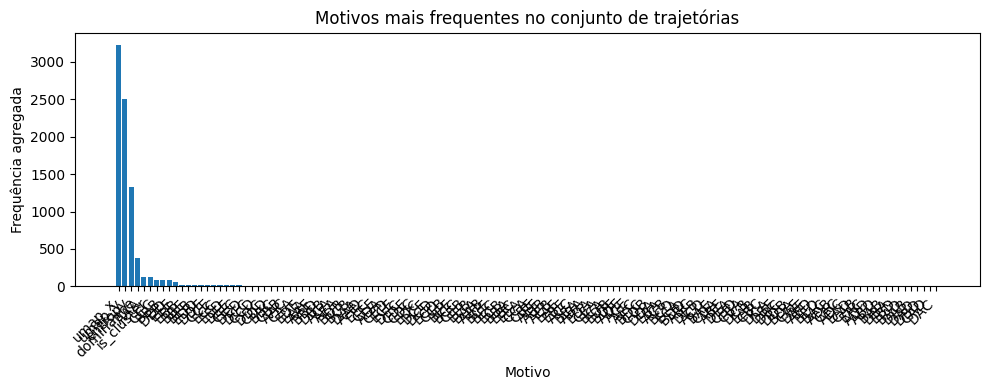

In [693]:
# ========================================================
# Frequência global dos motivos (motif_df já normalizado)
# ========================================================

import matplotlib.pyplot as plt

# --------------------------------------------------------
# Selecionar apenas colunas de motivos
# --------------------------------------------------------
motif_cols = [
    c for c in motif_df.columns
    if c not in ["user_id", "trajectory_id"]
]

# --------------------------------------------------------
# Soma das frequências relativas ao longo das trajetórias
# (equivale à frequência média ponderada por trajetória)
# --------------------------------------------------------
global_motif_freq = motif_df[motif_cols].sum().sort_values(ascending=False)

# --------------------------------------------------------
# Normalização opcional (percentual global)
# --------------------------------------------------------
global_motif_freq_pct = global_motif_freq / global_motif_freq.sum() * 100

# --------------------------------------------------------
# Print
# --------------------------------------------------------
freq_df = (
    global_motif_freq
    .to_frame(name="Frequência agregada")
    .assign(Frequência_percentual=global_motif_freq_pct)
)

print("Frequência global dos motivos (agregada em todas as trajetórias):")
display(freq_df.head(20))

# --------------------------------------------------------
# Plot
# --------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.bar(freq_df.index, freq_df["Frequência agregada"])
plt.xlabel("Motivo")
plt.ylabel("Frequência agregada")
plt.title("Motivos mais frequentes no conjunto de trajetórias")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [682]:
from scipy.stats import entropy

motif_cols = motif_df.columns.difference(
    ["user_id", "trajectory_id"]
)

motif_df["entropy"] = motif_df[motif_cols].apply(
    lambda x: entropy(x[x > 0]),
    axis=1
)

motif_df["dominance"] = motif_df[motif_cols].max(axis=1)


In [683]:
import umap

embedding = umap.UMAP(
    n_neighbors=2,
    min_dist=0.1,
    random_state=42
).fit_transform(
    motif_df[["entropy", "dominance"]]
)

motif_df["umap_x"] = embedding[:, 0]
motif_df["umap_y"] = embedding[:, 1]


C:\Users\ccana\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


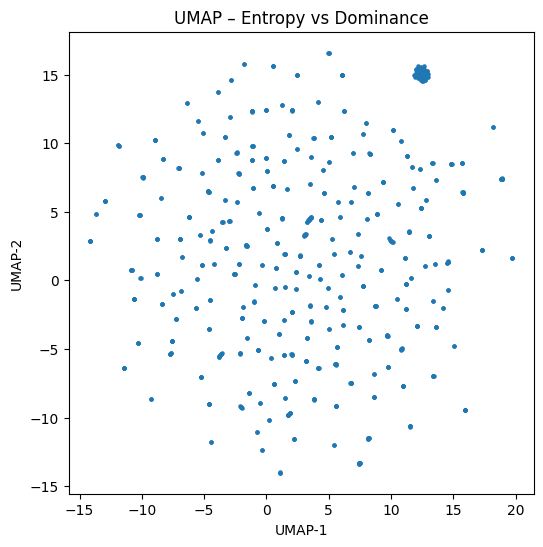

In [684]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(
    motif_df["umap_x"],
    motif_df["umap_y"],
    s=5
)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP – Entropy vs Dominance")
plt.show()


In [685]:
cluster = motif_df[
    (motif_df["umap_x"].between(7, 14)) &
    (motif_df["umap_y"].between(9, 17))
].copy()

cluster["is_cluster"] = True
motif_df["is_cluster"] = motif_df.index.isin(cluster.index)


In [686]:
from sklearn.linear_model import LinearRegression

'''def compute_vsl_slope(g):
    t = np.arange(len(g)).reshape(-1, 1)
    v = g["speed"].values.reshape(-1, 1)
    model = LinearRegression().fit(t, v)
    return model.coef_[0, 0]'''

def compute_vsl_slope(g):
    # Pega ponto inicial
    x0, y0 = g.iloc[0][["x", "y"]]
    
    # Calcula distância euclidiana do início até cada ponto t
    dists = np.sqrt((g["x"] - x0)**2 + (g["y"] - y0)**2)
    
    # Tempo (assumindo frames sequenciais como tempo)
    times = np.arange(1, len(g) + 1) # evita divisão por zero
    
    # VSL = Distancia Retilinea / Tempo
    vsl_series = dists / times
    
    # Regressão na série VSL
    model = LinearRegression().fit(times.reshape(-1, 1), vsl_series.values.reshape(-1, 1))
    return model.coef_[0, 0]

vsl_slope = (
    df_artigo
    .groupby(["user_id", "trajectory_id"])
    .apply(compute_vsl_slope)
    .reset_index(name="VSL_slope")
)


C:\Users\ccana\AppData\Local\Temp\ipykernel_45908\517577059.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_vsl_slope)


In [687]:
analysis_df = motif_df.merge(
    vsl_slope,
    on=["user_id", "trajectory_id"]
)


In [688]:
from scipy.stats import mannwhitneyu

mannwhitneyu(
    analysis_df.loc[analysis_df.is_cluster, "VSL_slope"],
    analysis_df.loc[~analysis_df.is_cluster, "VSL_slope"],
    alternative="two-sided"
)


MannwhitneyuResult(statistic=63914.0, pvalue=1.2154797095296068e-22)

In [689]:
analysis_df["DDD"] = analysis_df.get("DDD", 0)

analysis_df.groupby("is_cluster")["DDD"].mean()


is_cluster
False    0.126290
True     0.012176
Name: DDD, dtype: float64

In [690]:
summary = analysis_df.groupby("is_cluster").agg(
    VSL_median=("VSL_slope", "median"),
    VSL_iqr=("VSL_slope", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    entropy_mean=("entropy", "mean"),
    entropy_std=("entropy", "std"),
    dominance_mean=("dominance", "mean"),
    dominance_std=("dominance", "std"),
    DDD_mean=("DDD", "mean"),
    DDD_std=("DDD", "std"),
    n_tracks=("trajectory_id", "count")
)

summary


,VSL_median,VSL_iqr,entropy_mean,entropy_std,dominance_mean,dominance_std,DDD_mean,DDD_std,n_tracks
is_cluster,,,,,,,,,
False,-1.567126e-07,0.000002,1.909503,0.740365,0.395972,0.242358,0.126290,0.210193,688
True,0.000000e+00,0.000000,0.170365,0.527027,0.952067,0.159904,0.012176,0.085035,119


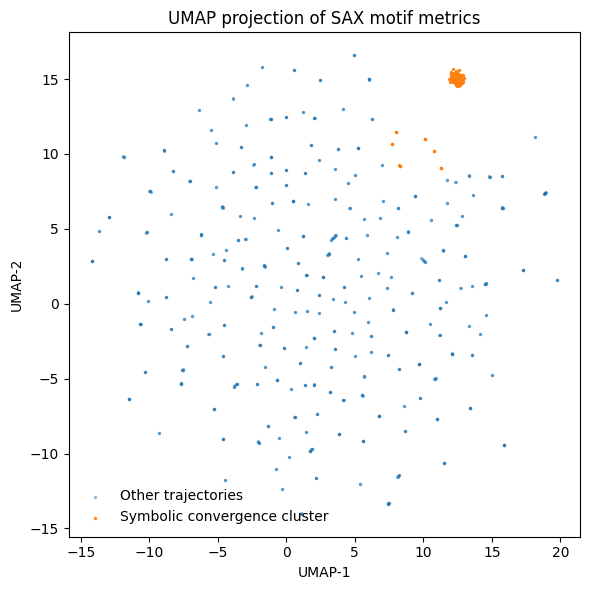

In [691]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Pontos fora do cluster compacto
plt.scatter(
    motif_df.loc[~motif_df["is_cluster"], "umap_x"],
    motif_df.loc[~motif_df["is_cluster"], "umap_y"],
    s=2,
    alpha=0.4,
    label="Other trajectories"
)

# Pontos do cluster compacto
plt.scatter(
    motif_df.loc[motif_df["is_cluster"], "umap_x"],
    motif_df.loc[motif_df["is_cluster"], "umap_y"],
    s=2,
    alpha=0.9,
    label="Symbolic convergence cluster"
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP projection of SAX motif metrics")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()


In [695]:
# ========================================================
# Identificação das trajetórias no cluster DDD
# ========================================================

# Filtrar apenas trajetórias no cluster
ddd_trajs = analysis_df.loc[
    analysis_df["is_cluster"], 
    ["user_id", "trajectory_id"]
]

print(f"Número de trajetórias no cluster DDD: {len(ddd_trajs)}")
display(ddd_trajs)

ddd_trajs.to_csv("ddd_trajs.csv")

Número de trajetórias no cluster DDD: 119


,user_id,trajectory_id
3,11,ckz6ru5610005386l8uoys4lc
4,11,ckz6ru6of0007386lhf2t4dtw
6,11,ckz6ru99l000b386l18xh2byu
14,11,ckz6rup8s000r386lkjotnoh0
18,11,ckz6ruzco0013386lo3nqjmle
...,...,...
777,82,cl3eig0jc000v3f6cph2jn9xc
796,82,cl3g4432m0003396c644k0st1
803,82,cl4za2v3u000c3y6fc6jz65yn
804,82,cl4za4fnb000g3y6frpvd1jm6
